# PCA Analysis of Clinical Features (`X_features.parquet`)

**Goal:** Understand the underlying structure of the 64 preprocessed features through PCA,
identify which clinical dimensions drive the most variance, and assess whether patients
cluster in ways that correlate with the 9 binary outcome endpoints.

**Dataset:** 4,579 PCI patients from the MASTER DAPT trial.
Features include 15 continuous clinical measurements, 48 binary indicators, and 1 categorical
variable (treatment regimen: abbreviated vs. prolonged DAPT).

**Sections:**
1. Data overview & feature groups
2. Correlation structure of continuous features
3. Preprocessing (log-transform skewed features, standard scaling)
4. PCA on continuous features — scree, loadings, biplot
5. PCA on all 70 features — scree comparison, loadings
6. Patient projections in PC space — clinical variables
7. Patient projections in PC space — outcome endpoints
8. PC score distributions by outcome (Mann-Whitney U)
9. Outlier detection via Hotelling's T²
10. Summary & recommendations

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, mannwhitneyu

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

In [2]:
PROJECT_DIR = os.path.dirname(os.getcwd())
sys.path.append(PROJECT_DIR)

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
with open("../data/removed_columns.txt", encoding="utf-8") as f:
    removed_cols = f.read().splitlines()

## 1. Data Overview

In [4]:
X = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/X_features.parquet'))
y = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/y_targets.parquet'))

print(f'Features matrix:  {X.shape[0]:,} patients × {X.shape[1]} features')
print(f'Targets matrix:   {y.shape[0]:,} patients × {y.shape[1]} endpoints')
print(f'Missing values in X: {X.isnull().sum().sum()}')
print()

target_info = pd.DataFrame({
    'n_events': y.sum().astype(int),
    'prevalence_%': (y.mean() * 100).round(1)
})
target_info.index.name = 'endpoint'
print('Target endpoint prevalences:')
display(target_info)

Features matrix:  4,579 patients × 64 features
Targets matrix:   4,579 patients × 9 endpoints
Missing values in X: 3364

Target endpoint prevalences:


,n_events,prevalence_%
endpoint,,
cec_barc235_335d,359,7.800
cec_cvdeath_335d,81,1.800
cec_mi_335d,109,2.400
cec_stroke_335d,35,0.800
cec_bleed_335d,506,11.100
cec_barc2_335d,254,5.500
cec_barc3_335d,112,2.400
cec_barc35_335d,122,2.700
cec_revasc_335d,162,3.500


In [5]:
# Continuous (quasi-numeric) features from schema_selected.py
CONTINUOUS_FEATURES = [
    'pci_tropo_pre', 'ic_age_mon', 'pci_platel_pre', 'fup_nyha', 'lvef',
    'heartrate', 'pci_glycemia', 'prec_hb', 'pci_creatinine_pre', 'prec_wbc',
    'bmi', 'pci_platelvol_pre', 'prior_mi', 'bp_sys', 'contrast',
    'pci_platelvol_ldis', 'prior_pci', 'prec_creatinine', 'pci_tropo_ldis',
    'height', 'fup_ccs'
]

CONTINUOUS_FEATURES = [c for c in CONTINUOUS_FEATURES if c not in removed_cols]

# Exploratory full-cohort median imputation of the (now un-imputed) numeric
# features. There is no train/test split in this descriptive notebook, so
# this is not leakage; predictive pipelines impute inside CV instead.
X[CONTINUOUS_FEATURES] = X[CONTINUOUS_FEATURES].fillna(X[CONTINUOUS_FEATURES].median())


BINARY_FEATURES = [c for c in X.columns
                   if c not in CONTINUOUS_FEATURES and c != 'regimen']

print(f'Continuous features:  {len(CONTINUOUS_FEATURES)}')
print(f'Binary features:      {len(BINARY_FEATURES)}')
print(f'Categorical features: 1  (regimen)')
print()

# Skewness of continuous features — highlights need for log-transform
X_cont_raw = X[CONTINUOUS_FEATURES].astype(float)
skew_df = X_cont_raw.skew().sort_values(ascending=False).rename('skewness').to_frame()
skew_df['needs_log'] = skew_df['skewness'].abs() > 2
print('Skewness of continuous features:')
display(skew_df)

Continuous features:  15
Binary features:      48
Categorical features: 1  (regimen)

Skewness of continuous features:


,skewness,needs_log
prec_wbc,51.176,True
pci_creatinine_pre,27.437,True
pci_glycemia,20.485,True
prec_creatinine,6.860,True
pci_platel_pre,2.232,True
prior_mi,2.071,True
heartrate,1.618,False
prior_pci,1.613,False
contrast,1.138,False
bmi,0.868,False


## 2. Correlation Structure of Continuous Features

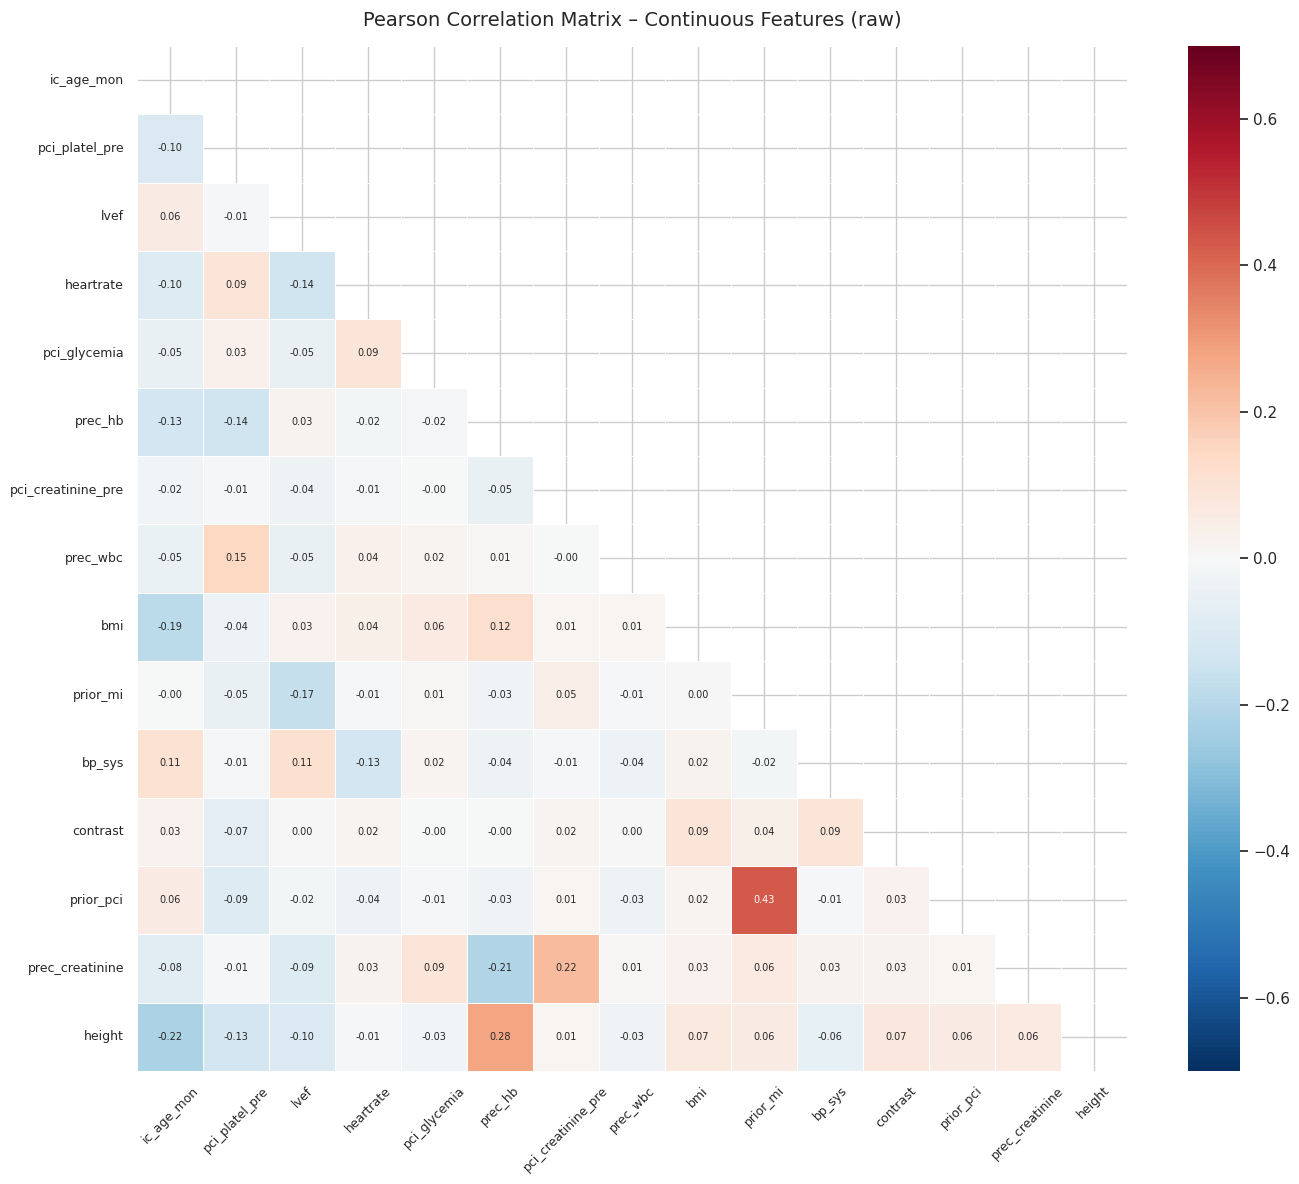

Top 10 strongest feature correlations (|r| > 0.3):


feature_1  feature_2
prior_pci  prior_mi    0.432
Name: |r|, dtype: float64

In [6]:
fig, ax = plt.subplots(figsize=(14, 12))

corr = X_cont_raw.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, ax=ax, linewidths=0.5, annot_kws={'size': 7},
    vmin=-0.7, vmax=0.7
)
ax.set_title('Pearson Correlation Matrix – Continuous Features (raw)', fontsize=14, pad=15)
ax.tick_params(axis='x', labelrotation=45, labelsize=9)
ax.tick_params(axis='y', labelrotation=0, labelsize=9)
plt.tight_layout()
plt.show()

# Highlight the highest absolute correlations
corr_abs = corr.abs().where(mask == False).stack()
corr_abs.index.names = ['feature_1', 'feature_2']
print('Top 10 strongest feature correlations (|r| > 0.3):')
display(corr_abs[corr_abs > 0.3].sort_values(ascending=False).head(10).rename('|r|'))

## 3. Preprocessing

PCA is sensitive to scale and skewness. Two transformations are applied:
- **Log1p transform** on features with |skew| > 2 (e.g., troponin, creatinine, WBC, platelet volume)
- **StandardScaler** (zero mean, unit variance) on all features before PCA

The `regimen` categorical column is binary-encoded (0 = abbreviated DAPT, 1 = prolonged DAPT)
and included in the full-feature PCA.

> **Note on mixed data:** PCA is strictly designed for continuous data. Applying it to a mix
> of binary and continuous features is a common pragmatic choice for exploratory work,
> but results should be interpreted with care. FAMD (Factor Analysis of Mixed Data) would
> be the theoretically correct alternative.

In [7]:
SKEWED_FEATURES = [
    'pci_tropo_pre', 'pci_tropo_ldis',    # troponin (extreme right skew)
    'pci_creatinine_pre', 'prec_creatinine', # creatinine
    'prec_wbc',                               # white blood cell count
    'pci_platelvol_pre', 'pci_platelvol_ldis', # platelet volume
    'pci_glycemia',                            # blood glucose
    'contrast',                                # contrast volume
    'fup_ccs',                                 # Canadian Cardiovascular Society class
    'pci_platel_pre',                          # platelet count
    'prior_mi', 'prior_pci',                  # count variables
    'fup_nyha',                                # NYHA class
]

# Keep only skewed features still present after the cleaning-pipeline drops.
SKEWED_FEATURES = [c for c in SKEWED_FEATURES if c in CONTINUOUS_FEATURES]

# ── Continuous-only matrix (log-transformed + scaled) ──────────────
X_cont = X[CONTINUOUS_FEATURES].astype(float).copy()
X_cont[SKEWED_FEATURES] = np.log1p(X_cont[SKEWED_FEATURES])

scaler_cont = StandardScaler()
X_cont_scaled = scaler_cont.fit_transform(X_cont)

# ── Full matrix (binary + log-cont + encoded regimen, scaled) ──────
X_all = X.copy()
# Encode regimen: 0 = abbreviated, 1 = prolonged
X_all['regimen'] = (X['regimen'] == 'prolonged DAPT').astype(float)
X_all[CONTINUOUS_FEATURES] = X_cont  # replace with log-transformed
X_all = X_all.astype(float)

scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)
feature_names_all = X_all.columns.tolist()

print('Preprocessing summary:')
print(f'  Log1p applied to {len(SKEWED_FEATURES)} skewed features')
print(f'  Continuous matrix shape: {X_cont_scaled.shape}')
print(f'  Full matrix shape:       {X_all_scaled.shape}')

Preprocessing summary:
  Log1p applied to 8 skewed features
  Continuous matrix shape: (4579, 15)
  Full matrix shape:       (4579, 64)


## 4. PCA – Continuous Features Only

In [8]:
pca_cont = PCA(random_state=RANDOM_STATE)
scores_cont = pca_cont.fit_transform(X_cont_scaled)

var_cont = pca_cont.explained_variance_ratio_
cumvar_cont = np.cumsum(var_cont) * 100

pcs_80 = int(np.argmax(cumvar_cont >= 80) + 1)
pcs_90 = int(np.argmax(cumvar_cont >= 90) + 1)
pcs_95 = int(np.argmax(cumvar_cont >= 95) + 1)

print(f'PCA on {len(CONTINUOUS_FEATURES)} continuous features')
print(f'  PC1 explains {var_cont[0]*100:.1f}% of variance')
print(f'  PC2 explains {var_cont[1]*100:.1f}% of variance')
print(f'  PC3 explains {var_cont[2]*100:.1f}% of variance')
print(f'  PCs needed for ≥80% variance: {pcs_80}')
print(f'  PCs needed for ≥90% variance: {pcs_90}')
print(f'  PCs needed for ≥95% variance: {pcs_95}')

PCA on 15 continuous features
  PC1 explains 13.5% of variance
  PC2 explains 11.1% of variance
  PC3 explains 10.3% of variance
  PCs needed for ≥80% variance: 10
  PCs needed for ≥90% variance: 12
  PCs needed for ≥95% variance: 13


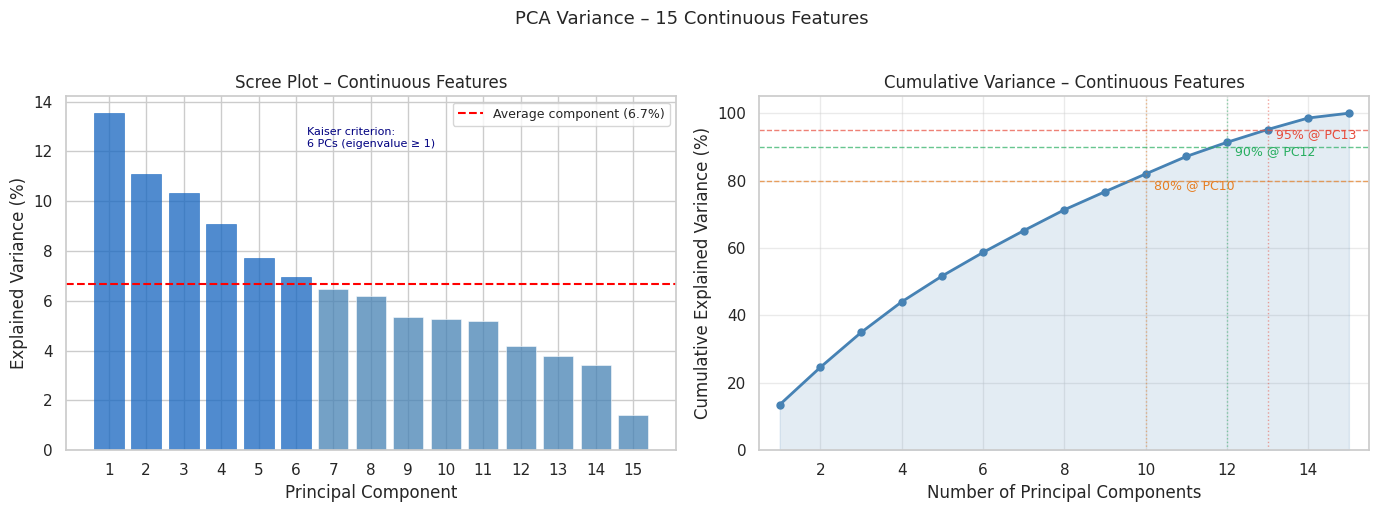

In [9]:
n_cont = len(CONTINUOUS_FEATURES)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Scree plot ---
bars = ax1.bar(range(1, n_cont + 1), var_cont * 100,
               color='steelblue', alpha=0.75, edgecolor='white', linewidth=0.5)
# Highlight first 8 (likely Kaiser criterion)
kaiser_n = int((pca_cont.explained_variance_ >= 1).sum())
for bar in bars[:kaiser_n]:
    bar.set_color('#1565C0')
ax1.axhline(y=100 / n_cont, color='red', linestyle='--', linewidth=1.5,
            label=f'Average component ({100/n_cont:.1f}%)')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Scree Plot – Continuous Features')
ax1.set_xticks(range(1, n_cont + 1))
ax1.legend(fontsize=9)
ax1.text(kaiser_n + 0.3, var_cont[0] * 100 * 0.9,
         f'Kaiser criterion:\n{kaiser_n} PCs (eigenvalue ≥ 1)', fontsize=8, color='navy')

# --- Cumulative variance ---
ax2.plot(range(1, n_cont + 1), cumvar_cont, 'o-', color='steelblue',
         linewidth=2, markersize=5)
ax2.fill_between(range(1, n_cont + 1), cumvar_cont, alpha=0.15, color='steelblue')
for threshold, color in [(80, '#E67E22'), (90, '#27AE60'), (95, '#E74C3C')]:
    n_pcs = int(np.argmax(cumvar_cont >= threshold) + 1)
    ax2.axhline(y=threshold, color=color, linestyle='--', alpha=0.7, linewidth=1)
    ax2.axvline(x=n_pcs, color=color, linestyle=':', alpha=0.5, linewidth=1)
    ax2.text(n_pcs + 0.2, threshold - 2.5, f'{threshold}% @ PC{n_pcs}',
             fontsize=9, color=color)
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_title('Cumulative Variance – Continuous Features')
ax2.set_xlim(0.5, n_cont + 0.5)
ax2.set_ylim(0, 105)
ax2.grid(True, alpha=0.4)

plt.suptitle(f'PCA Variance – {n_cont} Continuous Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

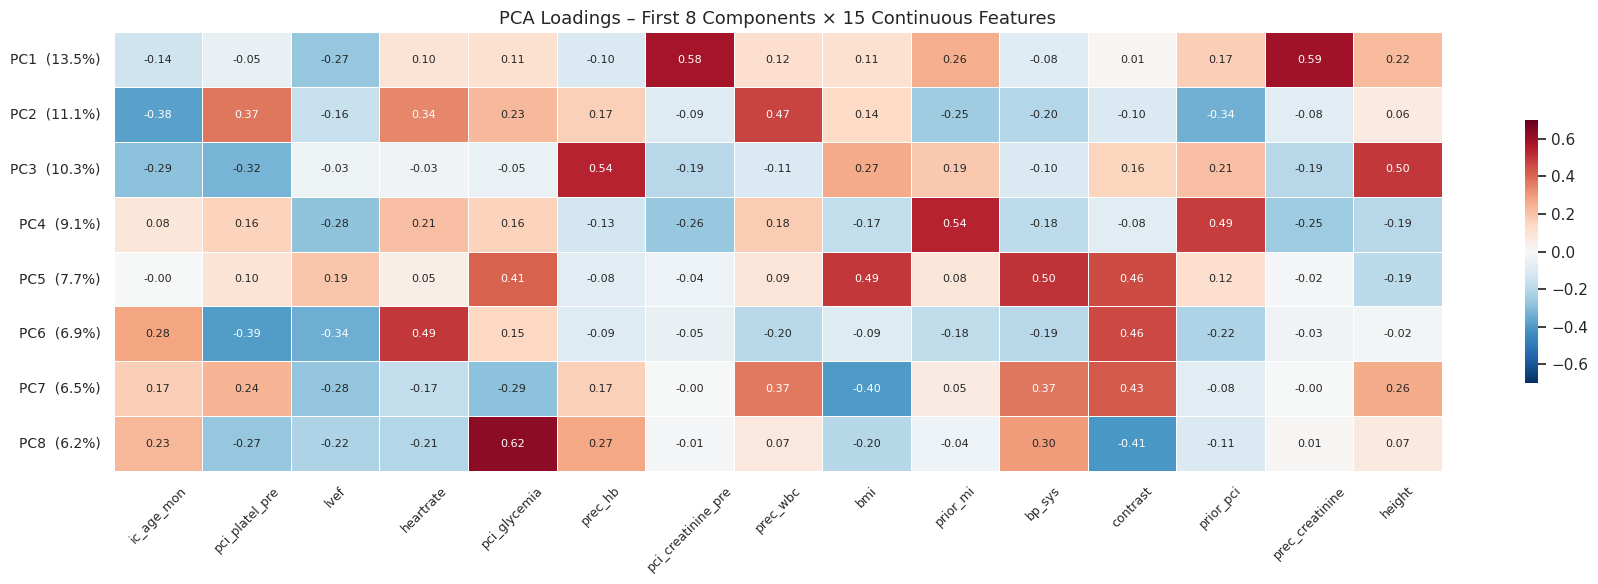

Top contributing features per PC:
  PC1: prec_creatinine (+0.59), pci_creatinine_pre (+0.58), prior_mi (+0.26) | lvef (-0.27), ic_age_mon (-0.14), prec_hb (-0.10)
  PC2: prec_wbc (+0.47), pci_platel_pre (+0.37), heartrate (+0.34) | ic_age_mon (-0.38), prior_pci (-0.34), prior_mi (-0.25)
  PC3: prec_hb (+0.54), height (+0.50), bmi (+0.27) | pci_platel_pre (-0.32), ic_age_mon (-0.29), prec_creatinine (-0.19)
  PC4: prior_mi (+0.54), prior_pci (+0.49), heartrate (+0.21) | lvef (-0.28), pci_creatinine_pre (-0.26), prec_creatinine (-0.25)
  PC5: bp_sys (+0.50), bmi (+0.49), contrast (+0.46) | height (-0.19), prec_hb (-0.08), pci_creatinine_pre (-0.04)
  PC6: heartrate (+0.49), contrast (+0.46), ic_age_mon (+0.28) | pci_platel_pre (-0.39), lvef (-0.34), prior_pci (-0.22)


In [10]:
n_pcs_show = 8
loadings_cont = pd.DataFrame(
    pca_cont.components_[:n_pcs_show],
    columns=CONTINUOUS_FEATURES,
    index=[f'PC{i+1}  ({var_cont[i]*100:.1f}%)' for i in range(n_pcs_show)]
)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    loadings_cont, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, ax=ax, linewidths=0.4, annot_kws={'size': 8},
    vmin=-0.7, vmax=0.7, cbar_kws={'shrink': 0.6}
)
ax.set_title(f'PCA Loadings – First {n_pcs_show} Components × {len(CONTINUOUS_FEATURES)} Continuous Features',
             fontsize=13)
ax.tick_params(axis='x', labelrotation=45, labelsize=9)
ax.tick_params(axis='y', labelrotation=0, labelsize=10)
plt.tight_layout()
plt.show()

# Print top 4 drivers per PC
print('Top contributing features per PC:')
for pc_idx in range(min(6, n_pcs_show)):
    loadings_row = pca_cont.components_[pc_idx]
    top_pos = np.argsort(loadings_row)[-3:][::-1]
    top_neg = np.argsort(loadings_row)[:3]
    pos_str = ', '.join(f'{CONTINUOUS_FEATURES[i]} (+{loadings_row[i]:.2f})' for i in top_pos)
    neg_str = ', '.join(f'{CONTINUOUS_FEATURES[i]} ({loadings_row[i]:.2f})' for i in top_neg)
    print(f'  PC{pc_idx+1}: {pos_str} | {neg_str}')

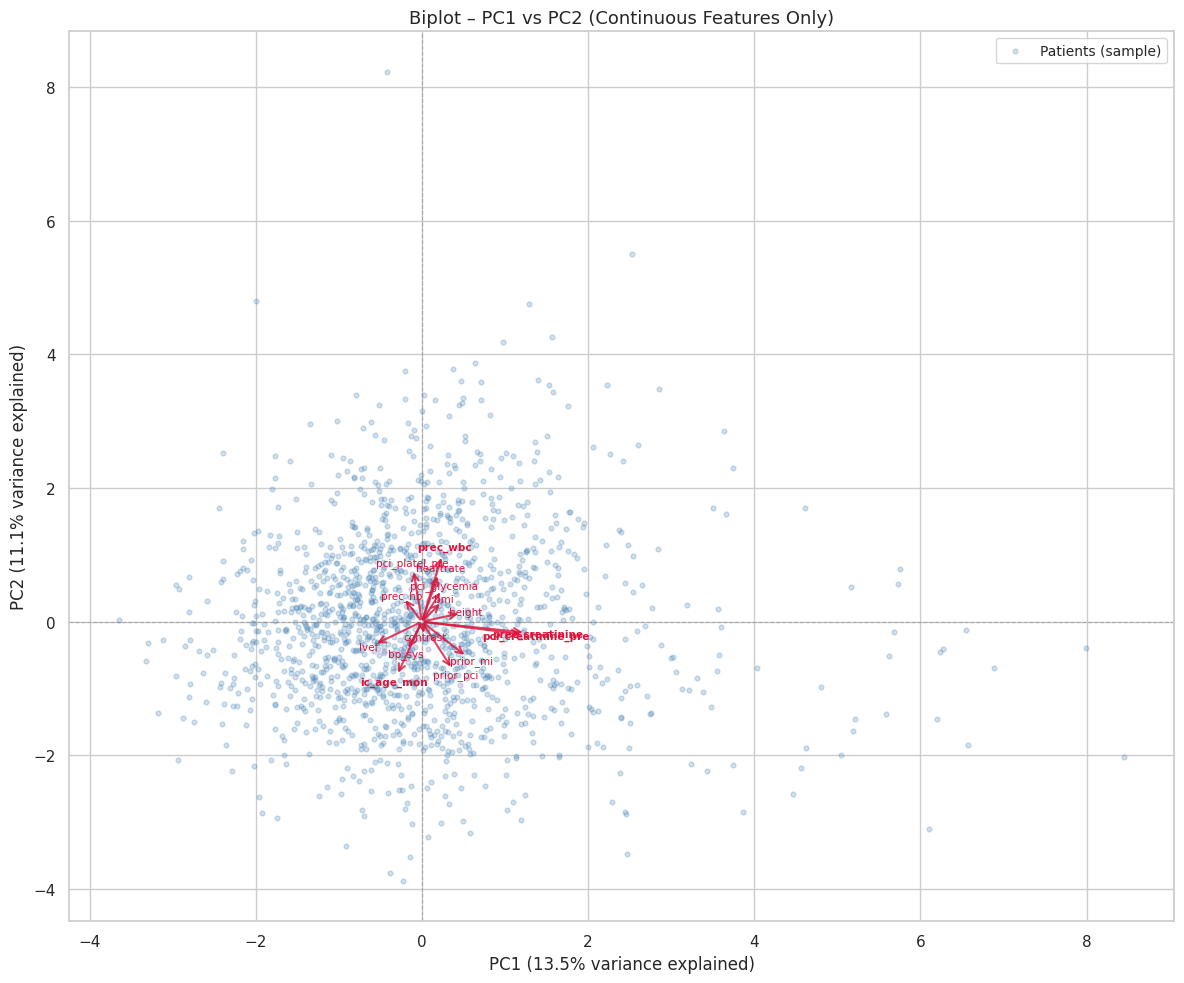

In [11]:
fig, ax = plt.subplots(figsize=(12, 10))

# Sample patients for scatter (avoid overplotting)
rng = np.random.default_rng(RANDOM_STATE)
idx_show = rng.choice(len(scores_cont), size=min(1500, len(scores_cont)), replace=False)
ax.scatter(
    scores_cont[idx_show, 0], scores_cont[idx_show, 1],
    alpha=0.25, s=12, color='steelblue', zorder=1, label='Patients (sample)'
)

# Loading arrows — scale to match patient cloud
score_scale = np.percentile(np.abs(scores_cont[:, :2]), 90)
components = pca_cont.components_[:2]

# Only label features with loading magnitude > 0.25 in either PC
loading_magnitude = np.sqrt(components[0]**2 + components[1]**2)
for i, feat in enumerate(CONTINUOUS_FEATURES):
    x_end = components[0, i] * score_scale
    y_end = components[1, i] * score_scale
    ax.annotate(
        '', xy=(x_end, y_end), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5, alpha=0.8),
        zorder=3
    )
    offset = 0.12
    ax.text(x_end * (1 + offset), y_end * (1 + offset), feat,
            fontsize=7.5, color='crimson', ha='center', va='center',
            fontweight='bold' if loading_magnitude[i] > 0.4 else 'normal')

var1 = var_cont[0] * 100
var2 = var_cont[1] * 100
ax.set_xlabel(f'PC1 ({var1:.1f}% variance explained)', fontsize=12)
ax.set_ylabel(f'PC2 ({var2:.1f}% variance explained)', fontsize=12)
ax.set_title('Biplot – PC1 vs PC2 (Continuous Features Only)', fontsize=13)
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 5. PCA – All 64 Features

In [12]:
pca_all = PCA(random_state=RANDOM_STATE)
scores_all = pca_all.fit_transform(X_all_scaled)

var_all = pca_all.explained_variance_ratio_
cumvar_all = np.cumsum(var_all) * 100

n_all = X_all_scaled.shape[1]
pcs_80_all = int(np.argmax(cumvar_all >= 80) + 1)
pcs_90_all = int(np.argmax(cumvar_all >= 90) + 1)

print(f'PCA on all {n_all} features (binary + continuous + regimen)')
print(f'  PC1 explains {var_all[0]*100:.1f}% of variance')
print(f'  PC2 explains {var_all[1]*100:.1f}% of variance')
print(f'  PCs needed for ≥80% variance: {pcs_80_all}')
print(f'  PCs needed for ≥90% variance: {pcs_90_all}')

PCA on all 64 features (binary + continuous + regimen)
  PC1 explains 5.9% of variance
  PC2 explains 5.3% of variance
  PCs needed for ≥80% variance: 34
  PCs needed for ≥90% variance: 42


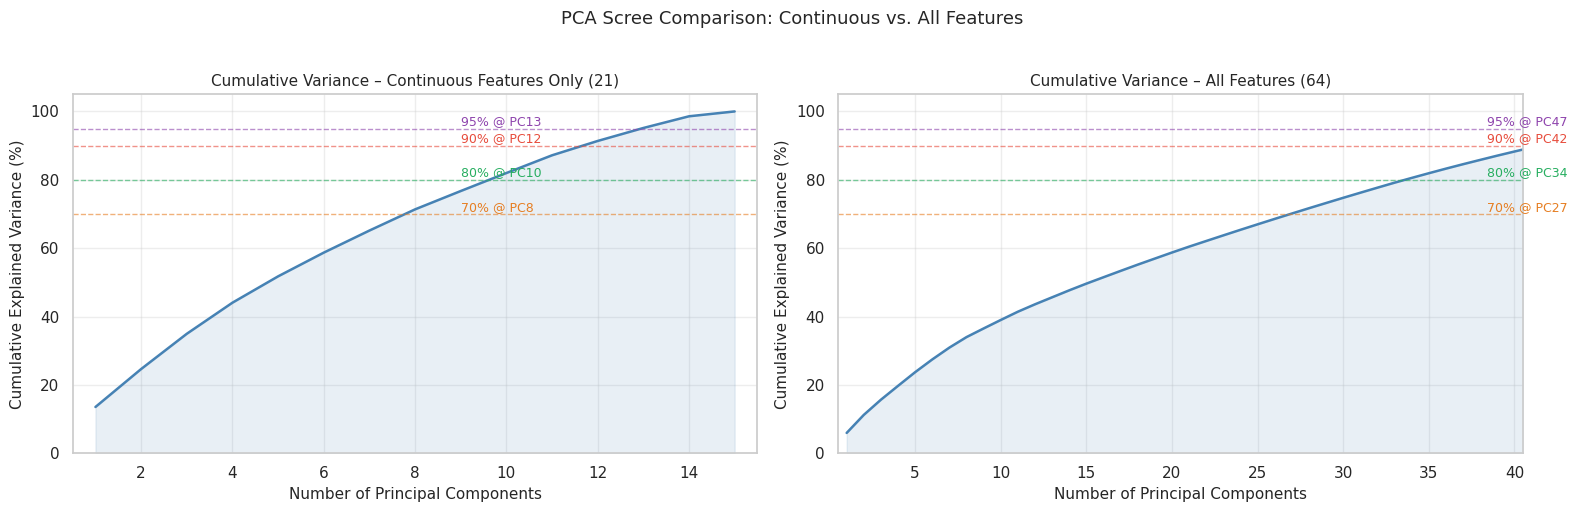

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

configs = [
    (pca_cont, cumvar_cont, len(CONTINUOUS_FEATURES), 'Continuous Features Only (21)'),
    (pca_all,  cumvar_all,  n_all,                    f'All Features ({n_all})'),
]

for ax, (pca_obj, cumvar, n_feat, label) in zip(axes, configs):
    ax.plot(range(1, n_feat + 1), cumvar, '-', linewidth=1.8, color='steelblue')
    ax.fill_between(range(1, n_feat + 1), cumvar, alpha=0.12, color='steelblue')
    for threshold, color in [(70, '#E67E22'), (80, '#27AE60'), (90, '#E74C3C'), (95, '#8E44AD')]:
        n_pcs = int(np.argmax(cumvar >= threshold) + 1)
        if n_pcs <= n_feat:
            ax.axhline(y=threshold, color=color, linestyle='--', alpha=0.6, linewidth=1)
            ax.text(n_feat * 0.6, threshold + 1, f'{threshold}% @ PC{n_pcs}',
                    fontsize=9, color=color)
    ax.set_xlabel('Number of Principal Components', fontsize=11)
    ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
    ax.set_title(f'Cumulative Variance – {label}', fontsize=11)
    ax.set_xlim(0.5, min(n_feat, 40) + 0.5)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.35)

plt.suptitle('PCA Scree Comparison: Continuous vs. All Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Index(['acs_acs_unstable_ang', 'acs_last_pci_acs_uns', 'p_bleed_action1_none',
       'p_bleed', 'prec_priorbleed', 'acs_Silent Ischemia',
       'acs_last_pci_silent', 'p_bleed_action1_rece', 'prior_mi_12m',
       'fup_insulin', 'acs_Stable angina', 'acs_last_pci_stable',
       'acs_ACS STEMI', 'prec_creatinine', 'height', 'acs_last_pci_acs_ste',
       'pci_creatinine_pre', 'race_caucasian_origi', 'race_Asian origin',
       'prec_hb', 'lvef', 'geography_Europe', 'diabetes_type_ii_in1',
       'gender_encoded', 'rand_anemia'],
      dtype='object')


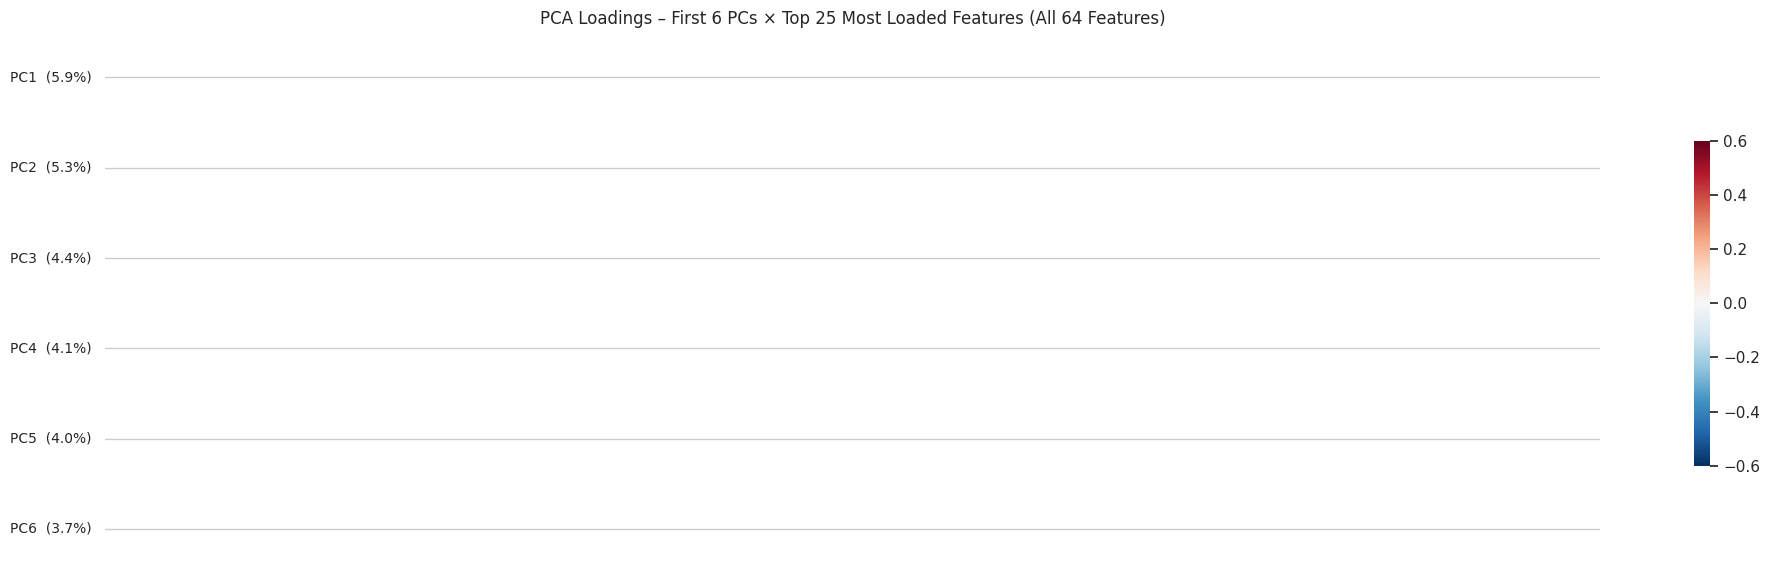

In [14]:
n_pcs_show = 6
top_n = 25  # top features by max absolute loading across first 6 PCs

loadings_all_df = pd.DataFrame(
    pca_all.components_[:n_pcs_show],
    columns=feature_names_all,
    index=[f'PC{i+1}  ({var_all[i]*100:.1f}%)' for i in range(n_pcs_show)]
)

# Select top features by max absolute loading
top_features_all = loadings_all_df.abs().max().nlargest(top_n).index.tolist()
loadings_top = loadings_all_df[top_features_all]

print(loadings_top.columns)

for name in loadings_top.columns:
    new_name = name[:20]  # truncate long names for better display
    loadings_top[new_name] = loadings_top[name]
    loadings_top.drop(columns=name, inplace=True)

fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(
    loadings_top, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, ax=ax, linewidths=0.4, annot_kws={'size': 8},
    vmin=-0.6, vmax=0.6, cbar_kws={'shrink': 0.6}
)
ax.set_title(
    f'PCA Loadings – First {n_pcs_show} PCs × Top {top_n} Most Loaded Features (All {n_all} Features)',
    fontsize=12
)
ax.tick_params(axis='x', labelrotation=45, labelsize=8)
ax.tick_params(axis='y', labelrotation=0, labelsize=10)
plt.tight_layout()
plt.show()

## 6. Patient Projections in PC Space – Clinical Variables

Color the PC1 vs PC2 scatter by key clinical variables to see whether PCA captures
meaningful clinical groupings (age, sex, treatment, ACS type, diabetes).

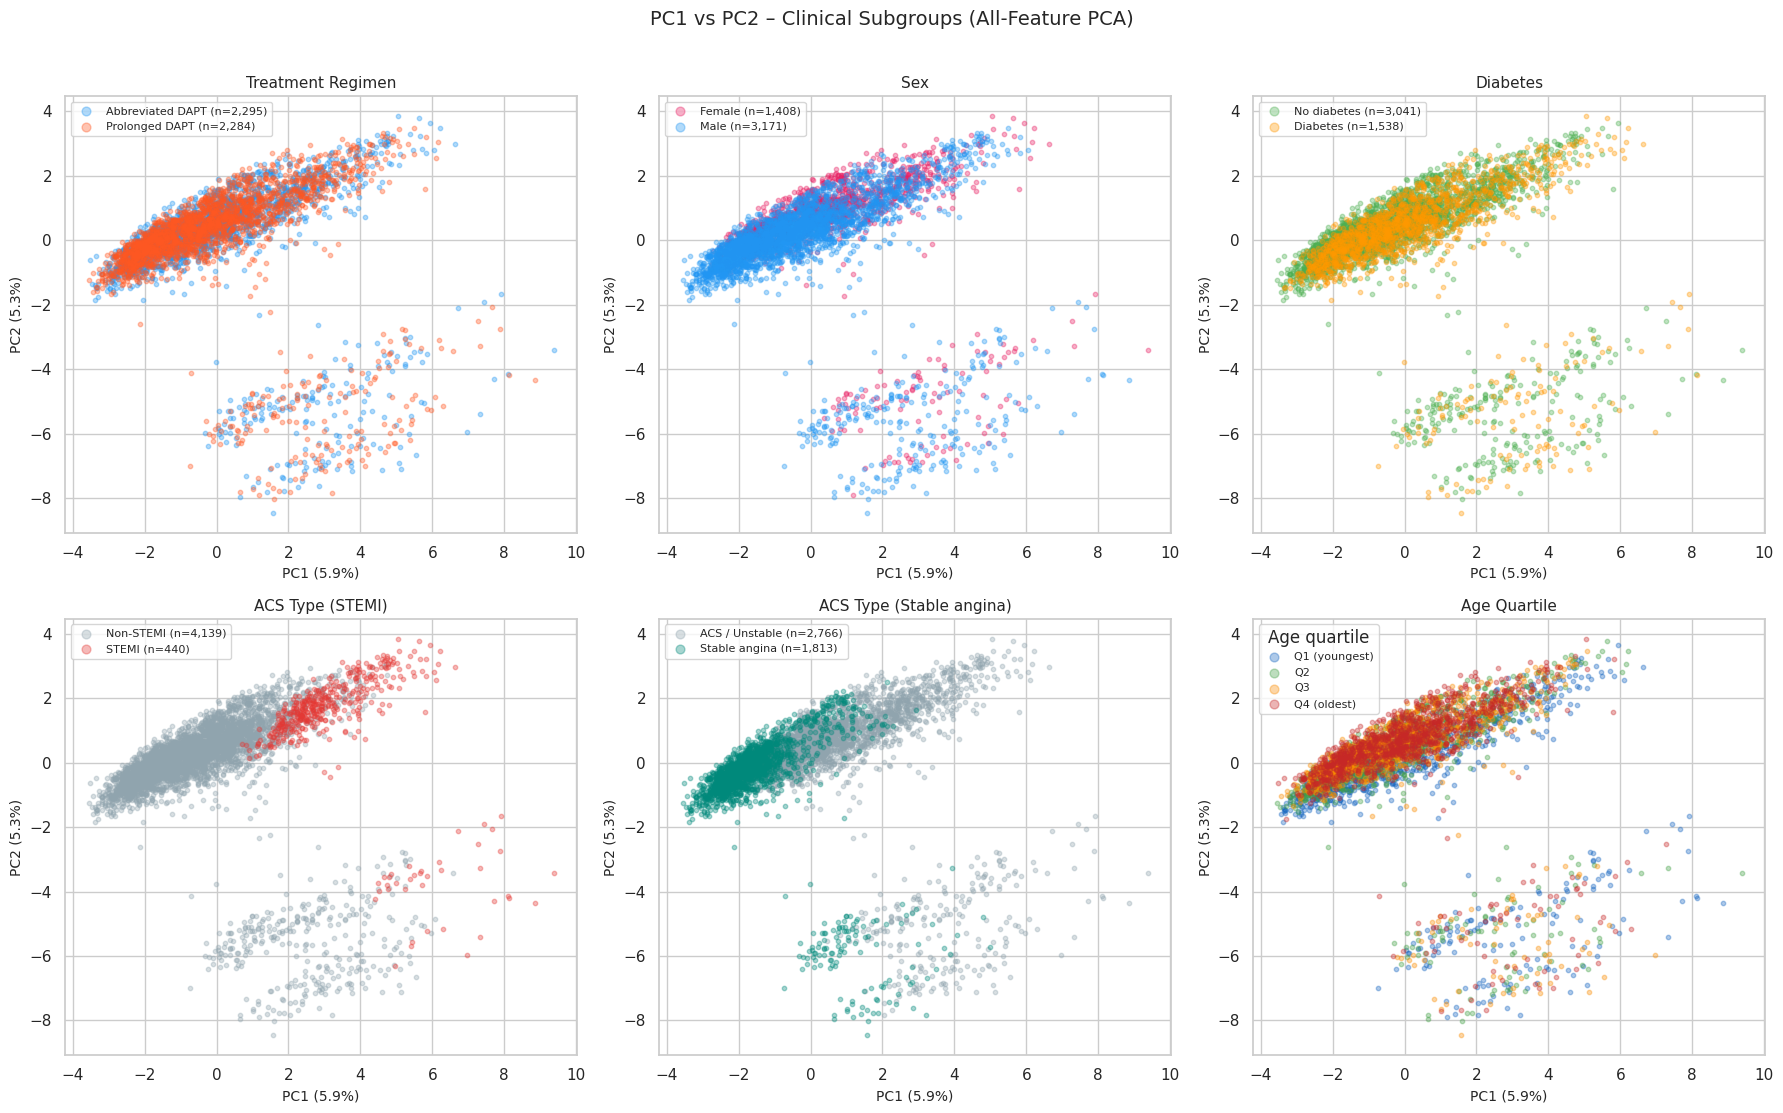

In [15]:
# Assemble clinical metadata for coloring
meta = pd.DataFrame(index=X.index)
meta['regimen']   = (X['regimen'] == 'prolonged DAPT').astype(int)  # 0=abbrev, 1=prolonged
meta['gender']    = X['gender_encoded'].astype(int)                  # likely 1=male, 0=female
meta['age_months'] = X['ic_age_mon'].astype(float)
meta['age_q']     = pd.qcut(meta['age_months'], 4, labels=['Q1 (youngest)', 'Q2', 'Q3', 'Q4 (oldest)'])

# Diabetes: any diabetes subtype
diab_cols = [c for c in X.columns if c.startswith('diabetes_')]
meta['diabetes']  = X[diab_cols].sum(axis=1).clip(0, 1).astype(int)

# ACS type at last PCI
meta['acs_stemi'] = X['acs_last_pci_acs_ste'].astype(int)
meta['acs_stable'] = X['acs_last_pci_stable'].astype(int)

# PC scores from full PCA
pc_df = pd.DataFrame(scores_all[:, :5], columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])

var1 = var_all[0] * 100
var2 = var_all[1] * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

def scatter_binary(ax, col, colors, labels, title):
    for val, c, lbl in zip([0, 1], colors, labels):
        mask = meta[col] == val
        ax.scatter(pc_df.loc[mask, 'PC1'], pc_df.loc[mask, 'PC2'],
                   c=c, alpha=0.35, s=10, label=f'{lbl} (n={mask.sum():,})')
    ax.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, markerscale=2)

scatter_binary(axes[0], 'regimen',  ['#2196F3', '#FF5722'],
               ['Abbreviated DAPT', 'Prolonged DAPT'], 'Treatment Regimen')

scatter_binary(axes[1], 'gender',   ['#E91E63', '#2196F3'],
               ['Female', 'Male'], 'Sex')

scatter_binary(axes[2], 'diabetes', ['#4CAF50', '#FF9800'],
               ['No diabetes', 'Diabetes'], 'Diabetes')

scatter_binary(axes[3], 'acs_stemi', ['#90A4AE', '#E53935'],
               ['Non-STEMI', 'STEMI'], 'ACS Type (STEMI)')

scatter_binary(axes[4], 'acs_stable', ['#90A4AE', '#00897B'],
               ['ACS / Unstable', 'Stable angina'], 'ACS Type (Stable angina)')

# Age quartile
ax = axes[5]
colors_age = ['#1565C0', '#43A047', '#FB8C00', '#C62828']
for j, q in enumerate(['Q1 (youngest)', 'Q2', 'Q3', 'Q4 (oldest)']):
    mask = meta['age_q'] == q
    ax.scatter(pc_df.loc[mask, 'PC1'], pc_df.loc[mask, 'PC2'],
               c=colors_age[j], alpha=0.35, s=10, label=q)
ax.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=10)
ax.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=10)
ax.set_title('Age Quartile', fontsize=11)
ax.legend(fontsize=8, markerscale=2, title='Age quartile')

plt.suptitle('PC1 vs PC2 – Clinical Subgroups (All-Feature PCA)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Patient Projections in PC Space – Outcome Endpoints

Color patients who experienced each clinical endpoint in red (event) vs. grey (no event).
If PCA captures prognostically relevant variance, event patients should cluster in specific
regions of PC space.

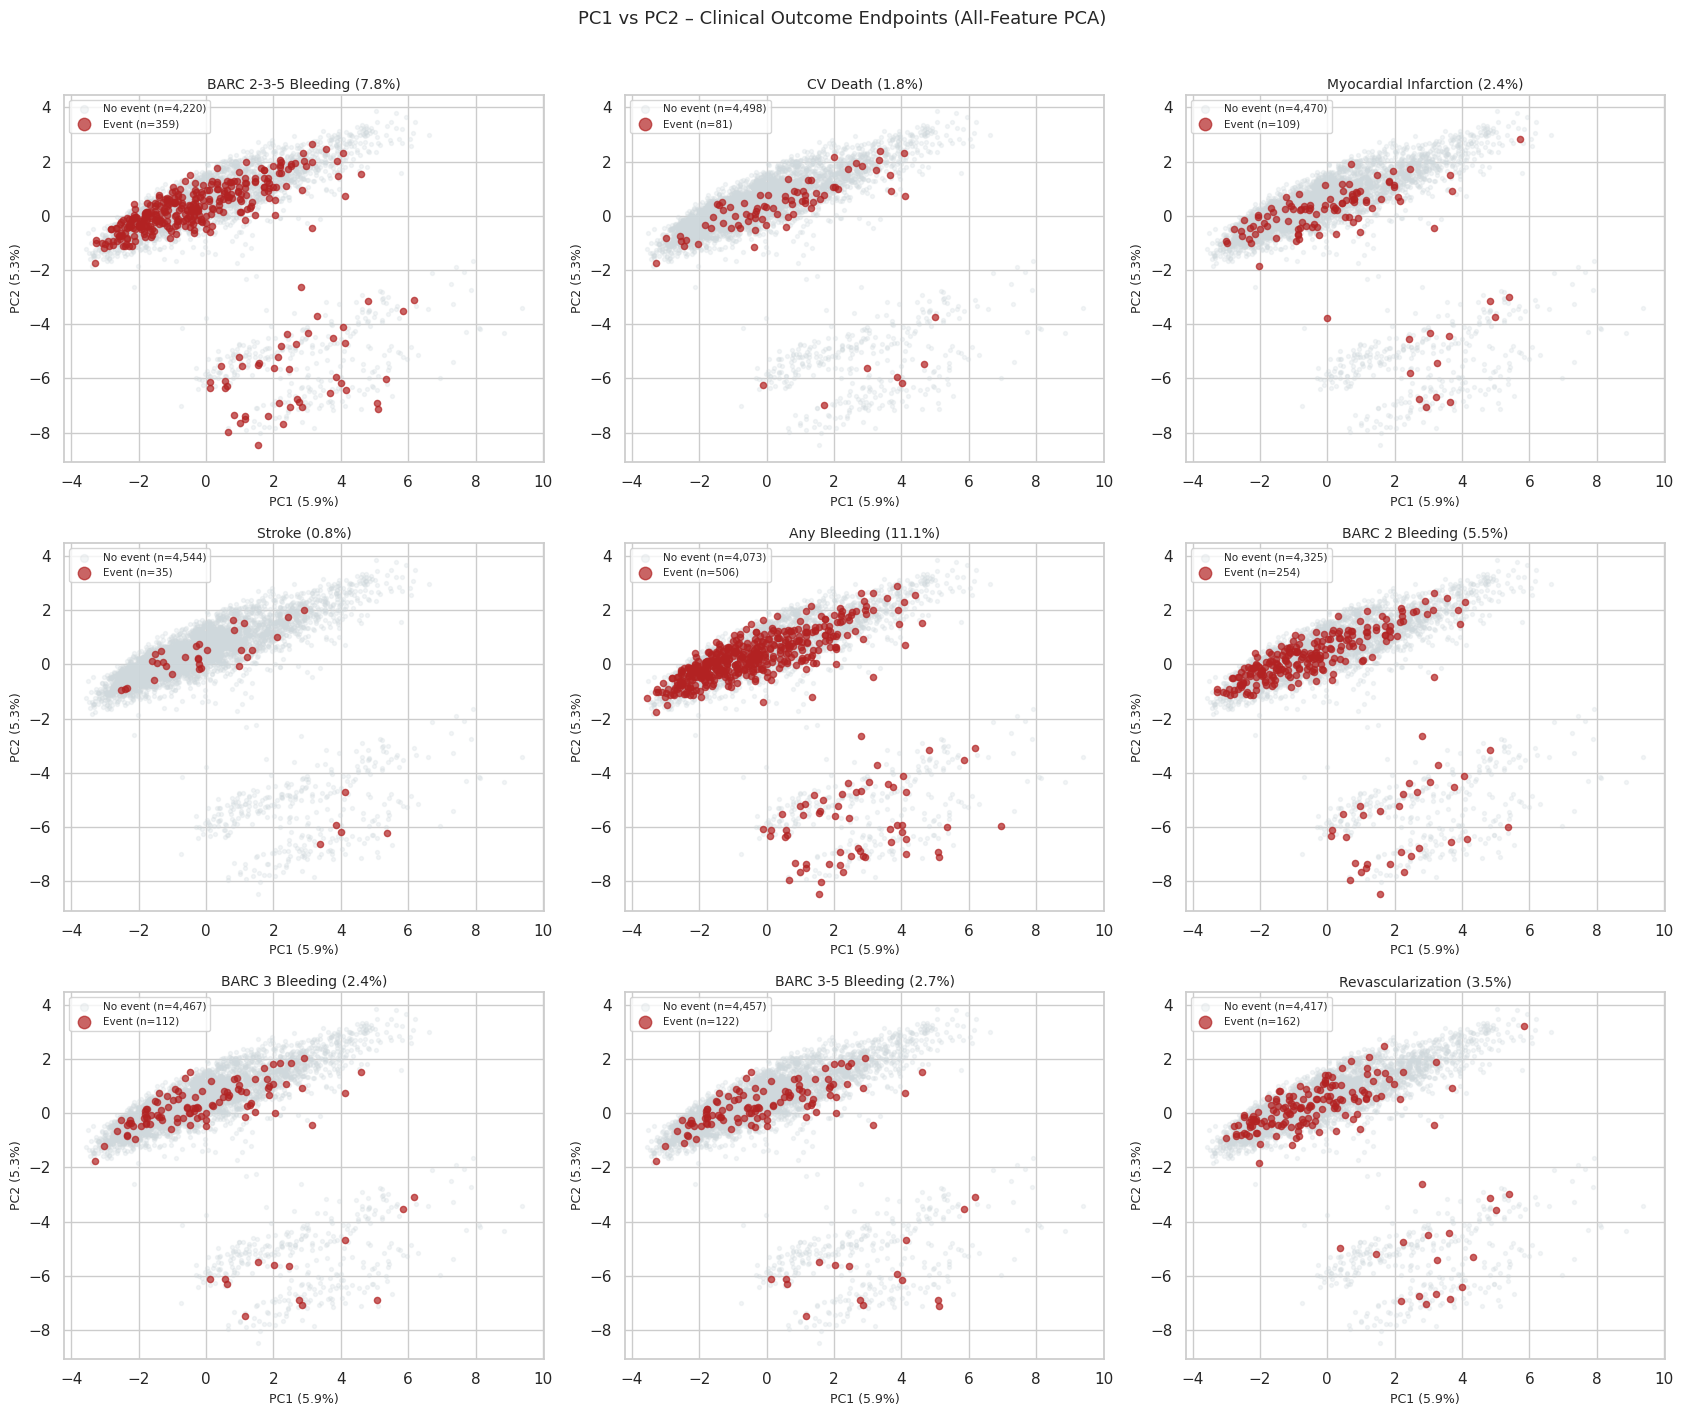

In [16]:
TARGET_LABELS = {
    'cec_barc235_335d': 'BARC 2-3-5 Bleeding (7.8%)',
    'cec_cvdeath_335d': 'CV Death (1.8%)',
    'cec_mi_335d':      'Myocardial Infarction (2.4%)',
    'cec_stroke_335d':  'Stroke (0.8%)',
    'cec_bleed_335d':   'Any Bleeding (11.1%)',
    'cec_barc2_335d':   'BARC 2 Bleeding (5.5%)',
    'cec_barc3_335d':   'BARC 3 Bleeding (2.4%)',
    'cec_barc35_335d':  'BARC 3-5 Bleeding (2.7%)',
    'cec_revasc_335d':  'Revascularization (3.5%)',
}

fig, axes = plt.subplots(3, 3, figsize=(17, 14))
axes = axes.flatten()

for i, (col, label) in enumerate(TARGET_LABELS.items()):
    ax = axes[i]
    y_col = y[col].astype(int).values
    n_event = y_col.sum()
    n_no_event = len(y_col) - n_event

    ax.scatter(
        pc_df.loc[y_col == 0, 'PC1'], pc_df.loc[y_col == 0, 'PC2'],
        c='#CFD8DC', alpha=0.25, s=8, label=f'No event (n={n_no_event:,})', zorder=1
    )
    ax.scatter(
        pc_df.loc[y_col == 1, 'PC1'], pc_df.loc[y_col == 1, 'PC2'],
        c='firebrick', alpha=0.7, s=20, label=f'Event (n={n_event})', zorder=2
    )
    ax.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=9)
    ax.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=9)
    ax.set_title(label, fontsize=10, pad=4)
    ax.legend(fontsize=7.5, markerscale=2)

plt.suptitle('PC1 vs PC2 – Clinical Outcome Endpoints (All-Feature PCA)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. PC Score Distributions by Outcome (Mann-Whitney U Test)

Even if 2D scatter plots show no clear separation, individual PCs may carry
statistically significant signal for specific endpoints. We test the first 5 PCs
against the 4 most prevalent endpoints using the Mann-Whitney U test.

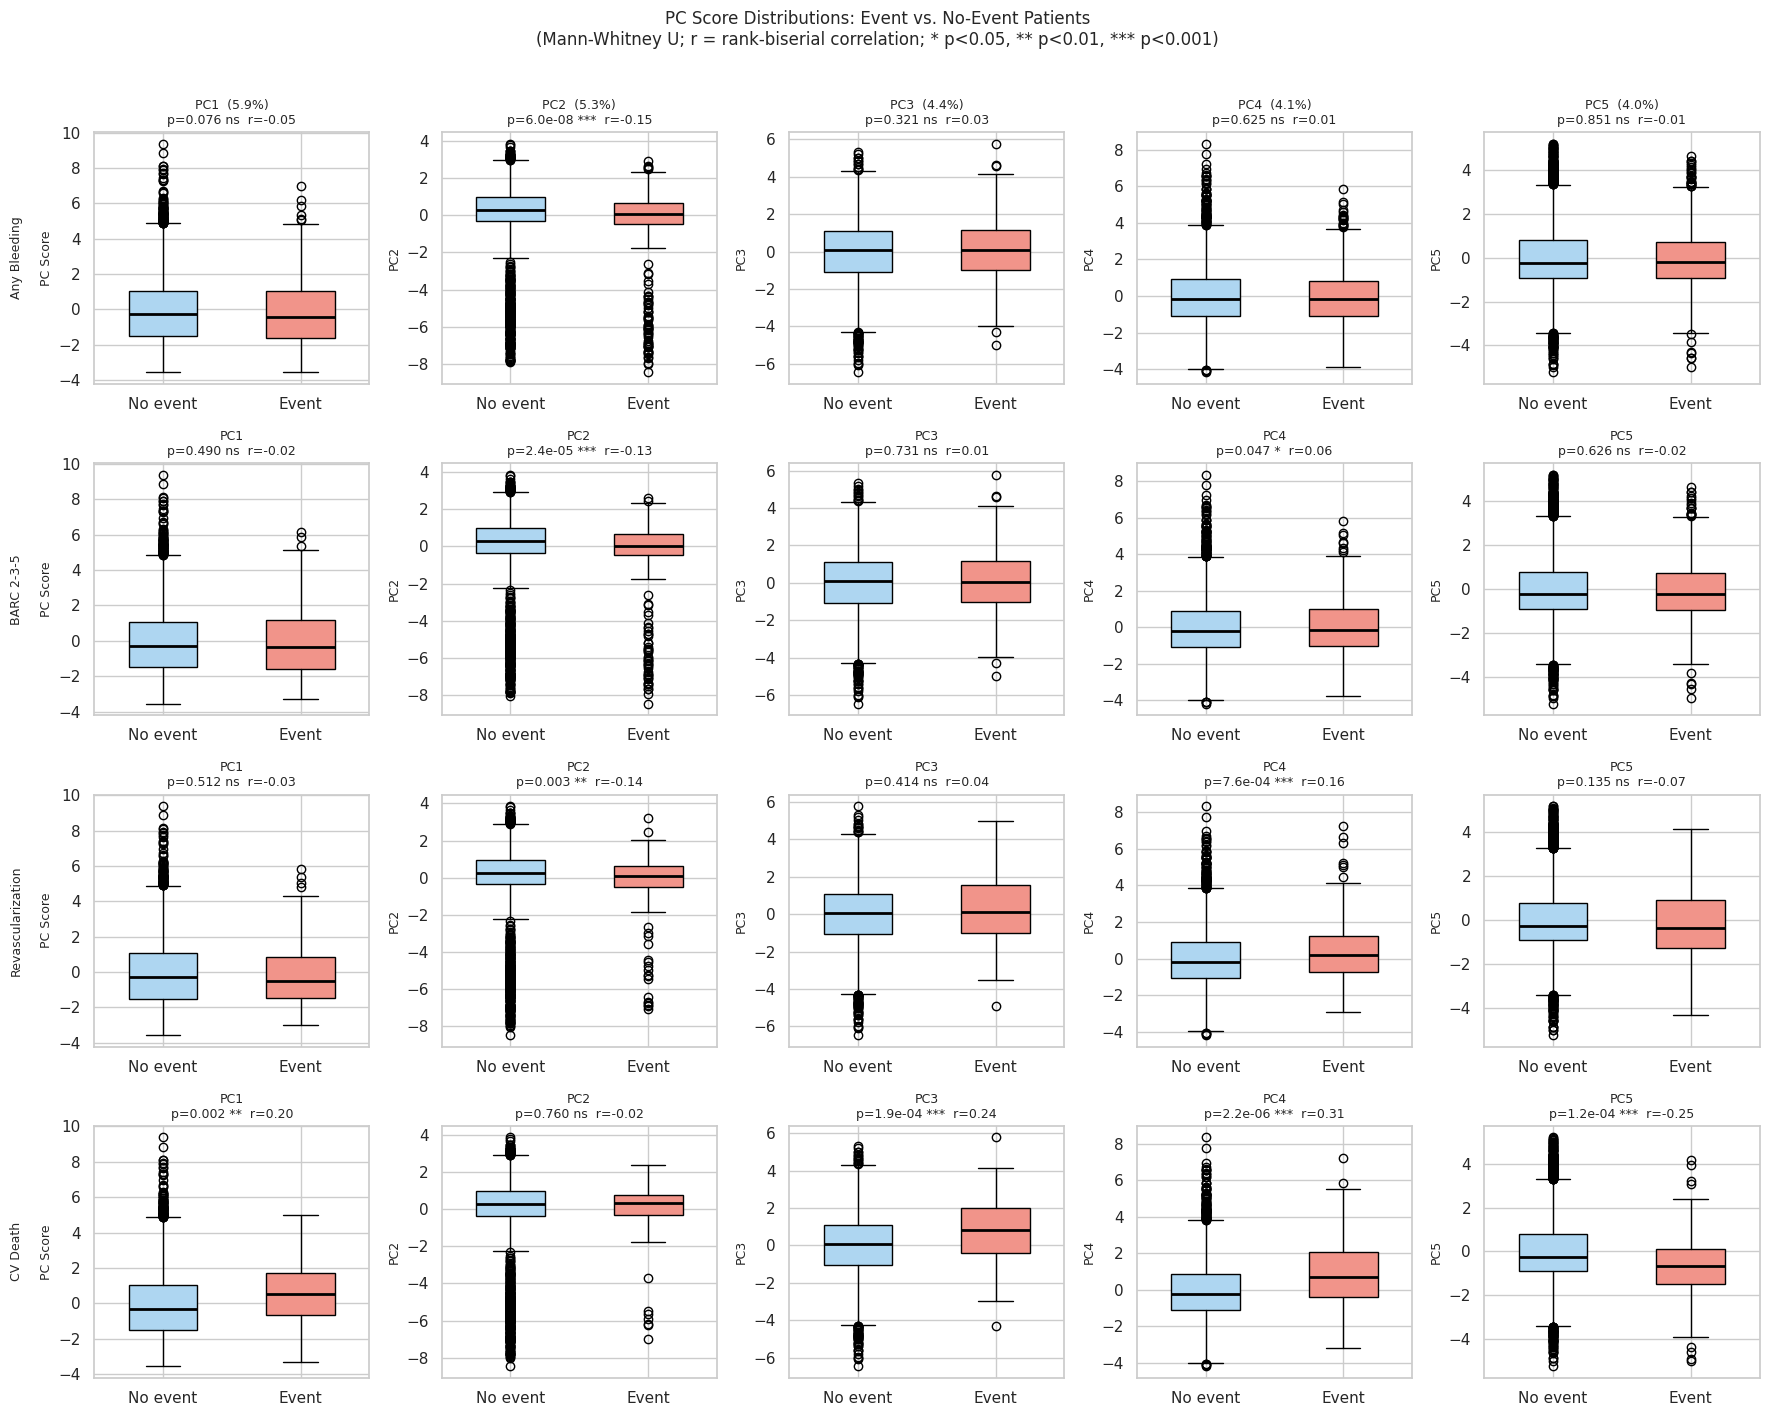

In [17]:
KEY_TARGETS = {
    'cec_bleed_335d':   'Any Bleeding',
    'cec_barc235_335d': 'BARC 2-3-5',
    'cec_revasc_335d':  'Revascularization',
    'cec_cvdeath_335d': 'CV Death',
}

N_PCS = 5
pc_score_df = pd.DataFrame(
    scores_all[:, :N_PCS],
    columns=[f'PC{i+1}' for i in range(N_PCS)]
)

fig, axes = plt.subplots(len(KEY_TARGETS), N_PCS,
                          figsize=(18, 3.5 * len(KEY_TARGETS)))

for row, (col, lbl) in enumerate(KEY_TARGETS.items()):
    y_col = y[col].astype(int).values
    group0 = pc_score_df[y_col == 0]
    group1 = pc_score_df[y_col == 1]

    for pc_idx in range(N_PCS):
        ax = axes[row, pc_idx]
        pc_name = f'PC{pc_idx+1}'

        g0 = group0[pc_name].values
        g1 = group1[pc_name].values

        bp = ax.boxplot(
            [g0, g1], labels=['No event', 'Event'],
            patch_artist=True, notch=False, widths=0.5,
            medianprops=dict(color='black', linewidth=2)
        )
        bp['boxes'][0].set_facecolor('#AED6F1')
        bp['boxes'][1].set_facecolor('#F1948A')

        stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
        # Effect size: rank-biserial correlation
        n0, n1 = len(g0), len(g1)
        r_rb = 1 - (2 * stat) / (n0 * n1)

        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        p_str = f'p={p:.1e}' if p < 0.001 else f'p={p:.3f}'
        ax.set_title(f'{pc_name}\n{p_str} {sig}  r={r_rb:.2f}', fontsize=9)
        ax.set_ylabel(pc_name, fontsize=9)
        if row == 0:
            ax.set_title(f'{pc_name}  ({var_all[pc_idx]*100:.1f}%)\n{p_str} {sig}  r={r_rb:.2f}',
                         fontsize=9)

    # Row label on leftmost plot
    axes[row, 0].set_ylabel(f'{lbl}\n\nPC Score', fontsize=9)

plt.suptitle(
    'PC Score Distributions: Event vs. No-Event Patients\n'
    '(Mann-Whitney U; r = rank-biserial correlation; * p<0.05, ** p<0.01, *** p<0.001)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

In [18]:
# Summary p-value table: which PCs discriminate which endpoints?
print('Mann-Whitney U p-values (PC1-5 × all 9 endpoints):')
print('Values below 0.05 indicate statistically significant separation')
print()

N_PCS_TABLE = 5
pval_data = {}
for col in y.columns:
    y_col = y[col].astype(int).values
    g0 = pc_score_df[y_col == 0]
    g1 = pc_score_df[y_col == 1]
    pvals = []
    for pc_idx in range(N_PCS_TABLE):
        pc_name = f'PC{pc_idx+1}'
        _, p = mannwhitneyu(g0[pc_name].values, g1[pc_name].values, alternative='two-sided')
        pvals.append(p)
    pval_data[col] = pvals

pval_df = pd.DataFrame(
    pval_data,
    index=[f'PC{i+1}' for i in range(N_PCS_TABLE)]
).T

# Style the table
def highlight_pvals(val):
    if val < 0.001:
        return 'background-color: #E74C3C; color: white'
    elif val < 0.01:
        return 'background-color: #F39C12; color: white'
    elif val < 0.05:
        return 'background-color: #F7DC6F'
    return ''

display(
    pval_df.style
    .format('{:.4f}')
    .applymap(highlight_pvals)
    .set_caption('p-values: red=p<0.001, orange=p<0.01, yellow=p<0.05')
)

Mann-Whitney U p-values (PC1-5 × all 9 endpoints):
Values below 0.05 indicate statistically significant separation



,PC1,PC2,PC3,PC4,PC5
cec_barc235_335d,0.4895,0.0000,0.7313,0.0469,0.6260
cec_cvdeath_335d,0.0019,0.7603,0.0002,0.0000,0.0001
cec_mi_335d,0.0810,0.0037,0.0002,0.0000,0.0000
cec_stroke_335d,0.1933,0.2368,0.7978,0.2339,0.1149
cec_bleed_335d,0.0758,0.0000,0.3208,0.6252,0.8507
cec_barc2_335d,0.0598,0.0002,0.8661,0.9664,0.1849
cec_barc3_335d,0.3609,0.0476,0.6413,0.0098,0.0014
cec_barc35_335d,0.1164,0.0234,0.4265,0.0007,0.0012
cec_revasc_335d,0.5116,0.0034,0.4141,0.0008,0.1352


## 9. Outlier Detection via Hotelling's T²

Hotelling's T² statistic identifies multivariate outliers in the reduced PC space.
It measures the squared Mahalanobis distance from the center in the first *k* PCs.
Under normality, T² ~ χ²(k), so a χ²(0.995) threshold flags the most extreme 0.5%.

Clinical note: outliers here represent patients with unusual combinations of
biomarker values — likely genuinely extreme disease states rather than data errors,
since missing values were already handled in the cleaning pipeline.

Hotelling's T² (first 10 PCs)
  χ²(99%, df=10)  threshold: 23.2  → 234 outliers
  χ²(99.5%, df=10) threshold: 25.2 → 178 outliers


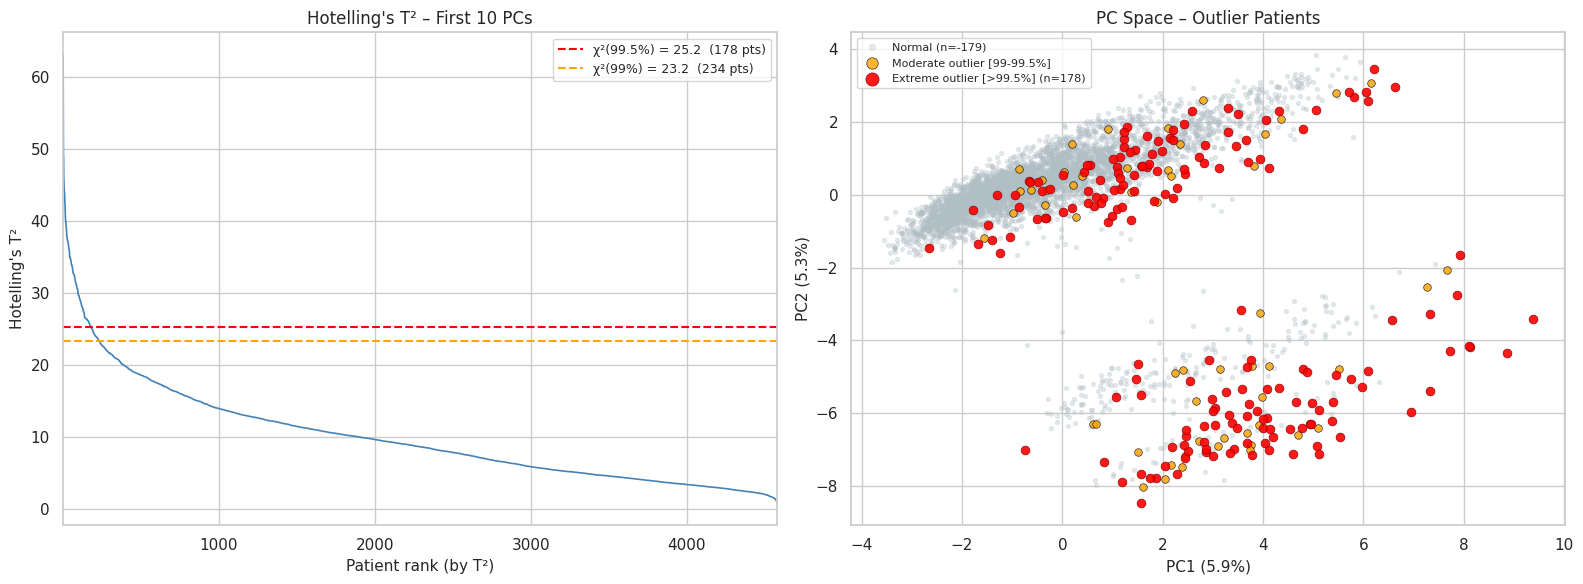

In [19]:
N_PCS_OUTLIER = 10  # use first 10 PCs

pc_scores_outlier = scores_all[:, :N_PCS_OUTLIER]
eigenvalues = pca_all.explained_variance_[:N_PCS_OUTLIER]

# Hotelling's T² = sum over PCs of (score / sqrt(eigenvalue))^2
T2 = np.sum((pc_scores_outlier / np.sqrt(eigenvalues)) ** 2, axis=1)

threshold_99  = chi2.ppf(0.99,  df=N_PCS_OUTLIER)
threshold_995 = chi2.ppf(0.995, df=N_PCS_OUTLIER)

outlier_mask_995 = T2 > threshold_995
outlier_mask_99  = T2 > threshold_99

print(f"Hotelling's T² (first {N_PCS_OUTLIER} PCs)")
print(f'  χ²(99%, df={N_PCS_OUTLIER})  threshold: {threshold_99:.1f}  → {outlier_mask_99.sum()} outliers')
print(f'  χ²(99.5%, df={N_PCS_OUTLIER}) threshold: {threshold_995:.1f} → {outlier_mask_995.sum()} outliers')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# T² distribution
ax = axes[0]
T2_sorted_idx = np.argsort(T2)[::-1]
ax.plot(range(1, len(T2) + 1), np.sort(T2)[::-1],
        '-', linewidth=1.2, color='steelblue')
ax.axhline(threshold_995, color='red', linestyle='--', linewidth=1.5,
           label=f'χ²(99.5%) = {threshold_995:.1f}  ({outlier_mask_995.sum()} pts)')
ax.axhline(threshold_99, color='orange', linestyle='--', linewidth=1.5,
           label=f'χ²(99%) = {threshold_99:.1f}  ({outlier_mask_99.sum()} pts)')
ax.set_xlabel('Patient rank (by T²)', fontsize=11)
ax.set_ylabel("Hotelling's T²", fontsize=11)
ax.set_title(f"Hotelling's T² – First {N_PCS_OUTLIER} PCs", fontsize=12)
ax.set_xlim(1, len(T2))
ax.legend(fontsize=9)

# PC1 vs PC2 with outliers highlighted
ax = axes[1]
ax.scatter(
    pc_df.loc[~outlier_mask_995, 'PC1'], pc_df.loc[~outlier_mask_995, 'PC2'],
    c='#B0BEC5', alpha=0.3, s=8, label=f'Normal (n={int(~outlier_mask_995.sum()):,})', zorder=1
)
ax.scatter(
    pc_df.loc[outlier_mask_99 & ~outlier_mask_995, 'PC1'],
    pc_df.loc[outlier_mask_99 & ~outlier_mask_995, 'PC2'],
    c='orange', alpha=0.8, s=30, label=f'Moderate outlier [99-99.5%]',
    edgecolors='black', linewidths=0.5, zorder=3
)
ax.scatter(
    pc_df.loc[outlier_mask_995, 'PC1'], pc_df.loc[outlier_mask_995, 'PC2'],
    c='red', alpha=0.9, s=40, label=f'Extreme outlier [>99.5%] (n={outlier_mask_995.sum()})',
    edgecolors='darkred', linewidths=0.5, zorder=4
)
ax.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=11)
ax.set_title('PC Space – Outlier Patients', fontsize=12)
ax.legend(fontsize=8, markerscale=1.5)

plt.tight_layout()
plt.show()

In [20]:
# Compare event rates between outliers and normal patients
print(f'Event rates: outliers (T² > {threshold_995:.0f}) vs. normal patients')
print('-' * 65)

comparison = []
for col in y.columns:
    y_col = y[col].astype(int).values
    rate_out  = y_col[outlier_mask_995].mean()
    rate_norm = y_col[~outlier_mask_995].mean()
    _, p_out = mannwhitneyu(
        y_col[outlier_mask_995].astype(float),
        y_col[~outlier_mask_995].astype(float),
        alternative='two-sided'
    ) if outlier_mask_995.sum() > 5 else (np.nan, np.nan)
    comparison.append({'endpoint': col,
                        'outlier_%': rate_out * 100,
                        'normal_%':  rate_norm * 100,
                        'ratio': rate_out / rate_norm if rate_norm > 0 else np.nan,
                        'p_value': p_out})

comp_df = pd.DataFrame(comparison).set_index('endpoint')
display(comp_df.style.format({'outlier_%': '{:.1f}', 'normal_%': '{:.1f}',
                               'ratio': '{:.2f}', 'p_value': '{:.4f}'}))

Event rates: outliers (T² > 25) vs. normal patients
-----------------------------------------------------------------


,outlier_%,normal_%,ratio,p_value
endpoint,,,,
cec_barc235_335d,15.7,7.5,2.09,0.0001
cec_cvdeath_335d,6.2,1.6,3.89,0.0000
cec_mi_335d,3.4,2.3,1.44,0.3767
cec_stroke_335d,2.2,0.7,3.19,0.0205
cec_bleed_335d,18.5,10.7,1.72,0.0012
cec_barc2_335d,7.3,5.5,1.33,0.2965
cec_barc3_335d,6.7,2.3,2.97,0.0002
cec_barc35_335d,8.4,2.4,3.47,0.0000
cec_revasc_335d,5.6,3.5,1.63,0.1255


## 10 t-SNE by Outcome Groups

We group the endpoints into three classes:
- `Normal`: no events.
- `Bleeding`: at least one bleeding event.
- `Ischemic`: at least one ischemic event and no bleeding events.

We apply t-SNE to the first 20 principal components of the full scaled matrix (`X_all_scaled`)
to visualize whether patients with bleeding or ischemic outcomes occupy different regions in the latent space.

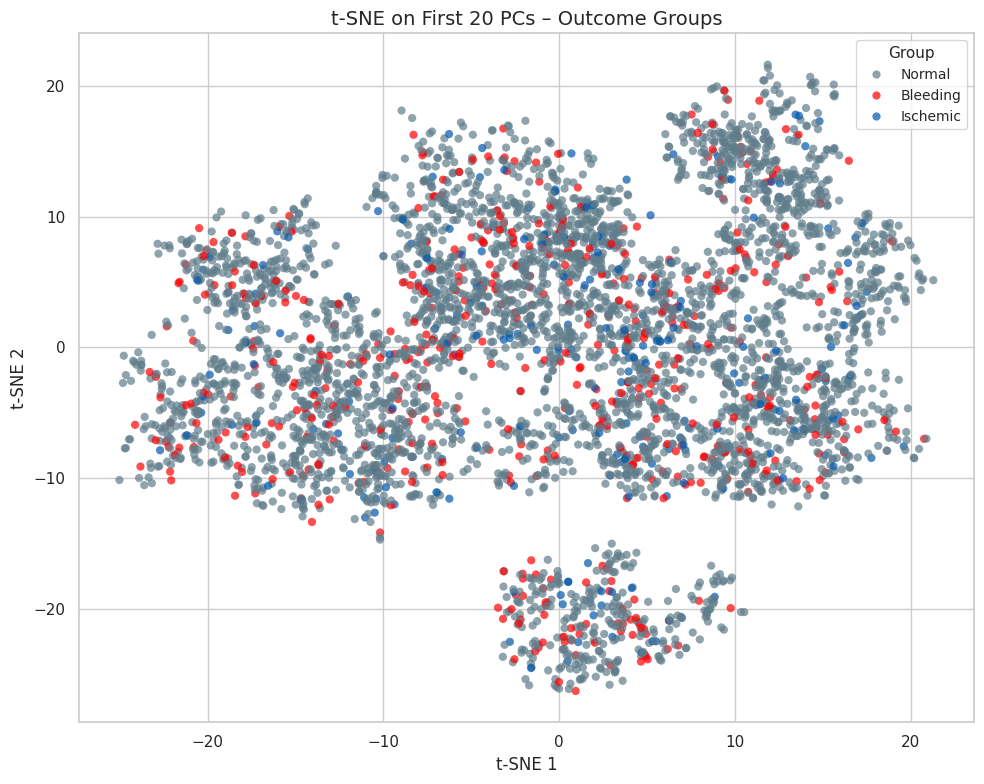

In [21]:
from sklearn.manifold import TSNE

bleeding_cols = [c for c in y.columns if 'bleed' in c or 'barc' in c]
ischemic_cols = ['cec_mi_335d', 'cec_stroke_335d', 'cec_cvdeath_335d', 'cec_revasc_335d']

bleeding_mask = y[bleeding_cols].sum(axis=1) > 0
ischemic_mask = y[ischemic_cols].sum(axis=1) > 0

group = pd.Series('Normal', index=y.index)
group[bleeding_mask] = 'Bleeding'
group[ischemic_mask & ~bleeding_mask] = 'Ischemic'

tsne = TSNE(
    n_components=3,
    perplexity=40,
    learning_rate='auto',
    random_state=RANDOM_STATE,
    init='pca'
)
X_tsne = tsne.fit_transform(scores_all[:, :20])

tsne_df = pd.DataFrame(X_tsne, index=y.index, columns=['TSNE1', 'TSNE2', 'TSNE3'])
tsne_df['group'] = group

fig, ax = plt.subplots(figsize=(10, 8))
palette = {'Normal': '#607D8B', 'Bleeding': "#FF0000", 'Ischemic': "#0258AD"}

sns.scatterplot(
    data=tsne_df,
    x='TSNE1', y='TSNE2',
    hue='group',
    palette=palette,
    alpha=0.7,
    s=35,
    edgecolor='none',
    ax=ax
)

ax.set_title('t-SNE on First 20 PCs – Outcome Groups', fontsize=14)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.legend(title='Group', fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.show()

## 11. UMAP – Comparison with t-SNE

UMAP (Uniform Manifold Approximation and Projection) is an alternative non-linear
dimensionality reduction method. Compared to t-SNE it is faster, preserves more of
the global structure, and is more deterministic across runs.

We apply UMAP to the same first 20 PCs used for t-SNE and compare the two embeddings
side-by-side for the three outcome groups (Normal / Bleeding / Ischemic).

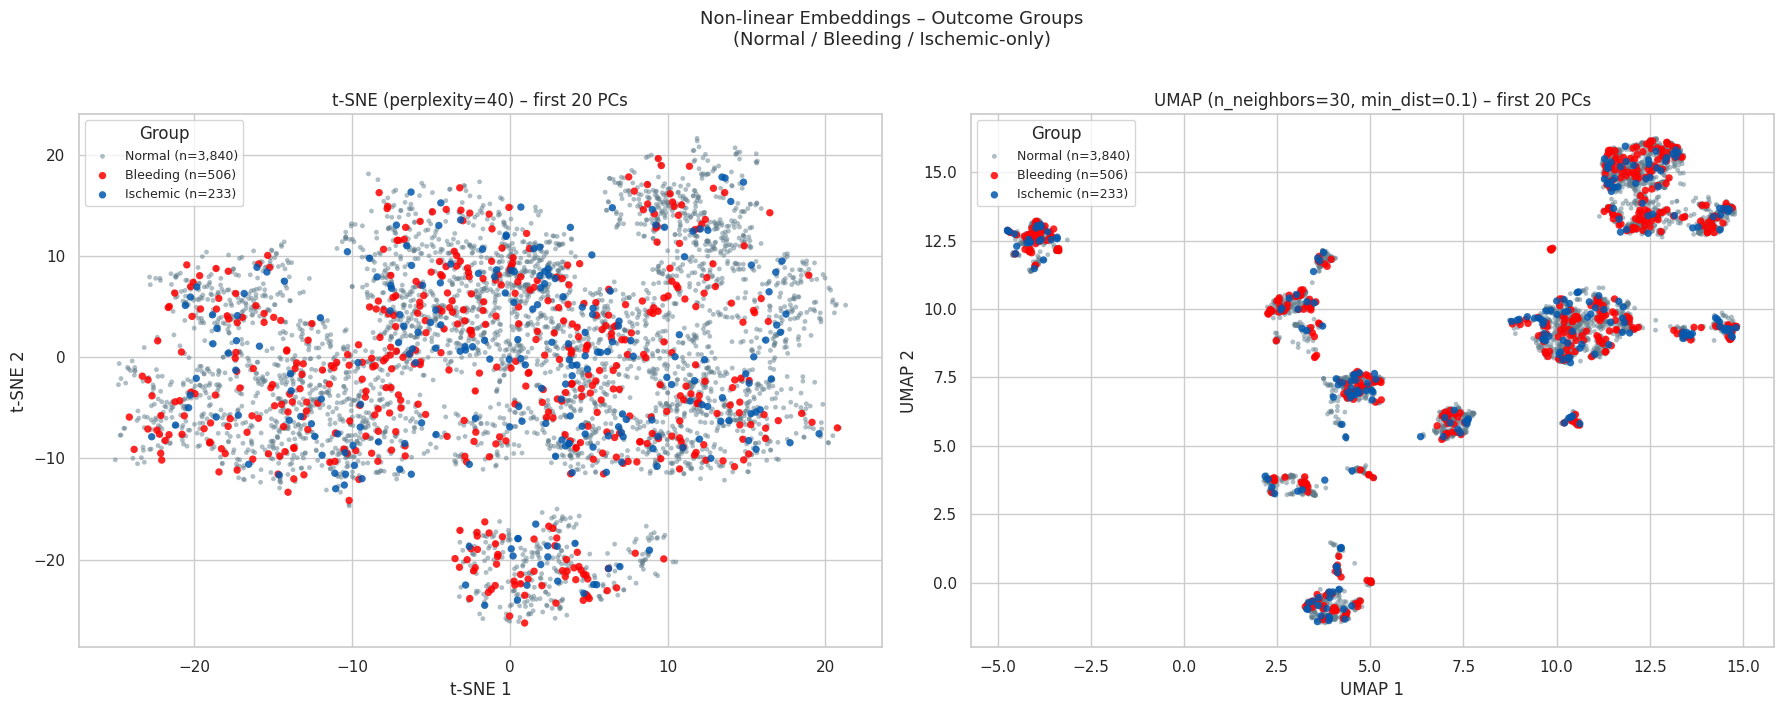

Group sizes: {'Normal': 3840, 'Bleeding': 506, 'Ischemic': 233}


In [22]:
import umap

bleeding_cols = [c for c in y.columns if 'bleed' in c or 'barc' in c]
ischemic_cols = ['cec_mi_335d', 'cec_stroke_335d', 'cec_cvdeath_335d', 'cec_revasc_335d']

bleeding_mask = y[bleeding_cols].sum(axis=1) > 0
ischemic_mask = y[ischemic_cols].sum(axis=1) > 0

group = pd.Series('Normal', index=y.index)
group[bleeding_mask] = 'Bleeding'
group[ischemic_mask & ~bleeding_mask] = 'Ischemic'

palette = {'Normal': '#607D8B', 'Bleeding': '#FF0000', 'Ischemic': '#0258AD'}

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    random_state=RANDOM_STATE
)
X_umap = reducer.fit_transform(scores_all[:, :20])
umap_df = pd.DataFrame(X_umap, index=y.index, columns=['UMAP1', 'UMAP2'])
umap_df['group'] = group.values

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- t-SNE (already computed) ---
ax = axes[0]
for grp, color in palette.items():
    mask = tsne_df['group'] == grp
    ax.scatter(tsne_df.loc[mask, 'TSNE1'], tsne_df.loc[mask, 'TSNE2'],
               c=color, alpha=0.5 if grp == 'Normal' else 0.85,
               s=12 if grp == 'Normal' else 28,
               label=f'{grp} (n={mask.sum():,})', edgecolors='none')
ax.set_title('t-SNE (perplexity=40) – first 20 PCs', fontsize=12)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(title='Group', fontsize=9)

# --- UMAP ---
ax = axes[1]
for grp, color in palette.items():
    mask = umap_df['group'] == grp
    ax.scatter(umap_df.loc[mask, 'UMAP1'], umap_df.loc[mask, 'UMAP2'],
               c=color, alpha=0.5 if grp == 'Normal' else 0.85,
               s=12 if grp == 'Normal' else 28,
               label=f'{grp} (n={mask.sum():,})', edgecolors='none')
ax.set_title('UMAP (n_neighbors=30, min_dist=0.1) – first 20 PCs', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(title='Group', fontsize=9)

plt.suptitle('Non-linear Embeddings – Outcome Groups\n(Normal / Bleeding / Ischemic-only)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Group sizes: {group.value_counts().to_dict()}')

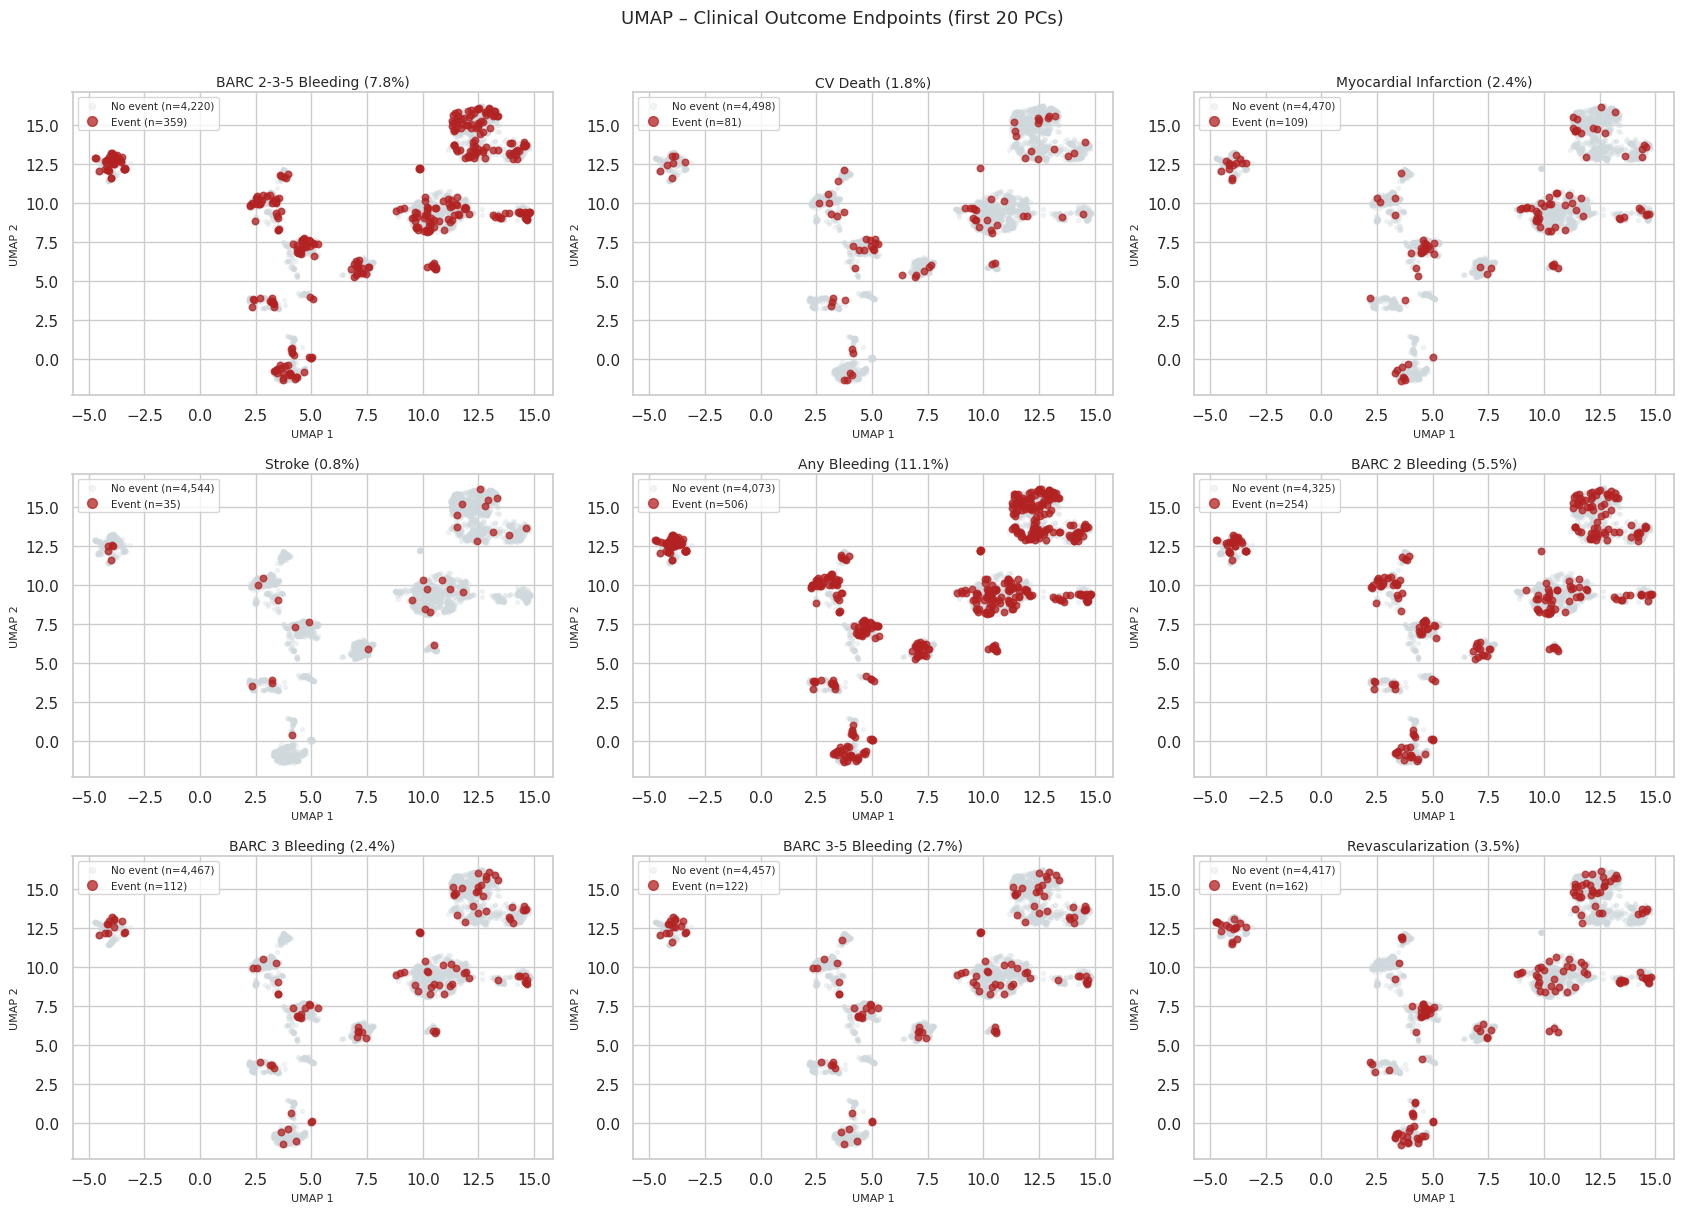

In [23]:
# UMAP colored by individual endpoints (same layout as section 7)
fig, axes = plt.subplots(3, 3, figsize=(17, 12))
axes = axes.flatten()

TARGET_LABELS = {
    'cec_barc235_335d': 'BARC 2-3-5 Bleeding (7.8%)',
    'cec_cvdeath_335d': 'CV Death (1.8%)',
    'cec_mi_335d':      'Myocardial Infarction (2.4%)',
    'cec_stroke_335d':  'Stroke (0.8%)',
    'cec_bleed_335d':   'Any Bleeding (11.1%)',
    'cec_barc2_335d':   'BARC 2 Bleeding (5.5%)',
    'cec_barc3_335d':   'BARC 3 Bleeding (2.4%)',
    'cec_barc35_335d':  'BARC 3-5 Bleeding (2.7%)',
    'cec_revasc_335d':  'Revascularization (3.5%)',
}

for i, (col, label) in enumerate(TARGET_LABELS.items()):
    ax = axes[i]
    y_col = y[col].astype(int).values
    n_event = y_col.sum()

    ax.scatter(umap_df.loc[y_col == 0, 'UMAP1'], umap_df.loc[y_col == 0, 'UMAP2'],
               c='#CFD8DC', alpha=0.25, s=8,
               label=f'No event (n={len(y_col) - n_event:,})', zorder=1)
    ax.scatter(umap_df.loc[y_col == 1, 'UMAP1'], umap_df.loc[y_col == 1, 'UMAP2'],
               c='firebrick', alpha=0.75, s=22,
               label=f'Event (n={n_event})', zorder=2)
    ax.set_title(label, fontsize=10, pad=4)
    ax.set_xlabel('UMAP 1', fontsize=8); ax.set_ylabel('UMAP 2', fontsize=8)
    ax.legend(fontsize=7.5, markerscale=1.5)

plt.suptitle('UMAP – Clinical Outcome Endpoints (first 20 PCs)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 12. Summary & Recommendations

### Variance Structure
- **Continuous-feature PCA:** A moderate number of PCs is needed to capture 80–90% of variance in the 21 continuous features, indicating the data is not strongly correlated (no single dominant axis).
- **All-feature PCA:** With 70 mixed features, more PCs are required for the same explained variance — binary features dilute the continuous signal.
- The first PC in the continuous-only PCA is dominated by **kidney function markers** (creatinine pre/post) and **cardiac injury markers** (troponin), reflecting the known co-morbidity pattern in PCI patients.

### Clinical Groupings
- **Treatment regimen** (abbreviated vs. prolonged DAPT) shows minimal separation in PC space — consistent with the trial's balanced randomization design.
- **ACS presentation type** (STEMI vs. stable angina) tends to cluster differently, especially along the troponin/creatinine axis.
- **Age** shows gradual gradient along PC1-2, confirming age's role as a broad risk factor.

### Outcome Separation
- The 2D scatter plots reveal **no sharp clustering** for any endpoint — consistent with the difficulty of predicting rare binary events in this population.
- The Mann-Whitney U tests identify specific PC–endpoint associations; statistically significant PCs likely represent clinically meaningful risk dimensions.
- **Bleeding endpoints** tend to be better separated than **ischemic endpoints**, consistent with known clinical predictors (hemoglobin, creatinine, platelet volume).
- Both **t-SNE** and **UMAP** embeddings confirm the absence of clean class separation: event patients scatter across the entire low-dimensional manifold, with no distinct cluster visible for any endpoint.

### Outliers
- Extreme Hotelling's T² outliers represent patients with exceptional biomarker values (e.g., critically elevated creatinine or troponin).
- These are likely genuine clinical extremes rather than data quality issues.
- Check if these outliers disproportionately drive event rates — if so, consider **robust PCA** or **winsorizing** extreme values before ML model training.

### Recommendations for ML Pipeline
1. **Log-transform** the highly skewed biomarkers before scaling (troponin, creatinine, WBC, platelet volume).
2. Consider **PCA-based dimensionality reduction** as an alternative feature representation (first ~8–12 continuous PCs ≈ 80%+ of variance).
3. The lack of clear PC-space separation underscores that **non-linear models** (gradient boosting, neural networks) are likely necessary for meaningful predictive performance.
4. Investigate the extreme outlier patients separately — they may require **special treatment** (e.g., clinical-risk stratification) before modeling.